In [1]:
import earthkit.data
import earthkit.plots
import earthkit.regrid

/home/ubuntu/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
from destinelab import climate_dt_dictionary
import ipywidgets as widgets
import json
import datetime

import importlib.metadata

In [3]:
import numpy as np
from netCDF4 import Dataset
import  matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import warnings
import datetime
import time # for sleep
import os.path # for basename
import glob
import xarray as xr
from numpy import savetxt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
from PIL import Image
from global_land_mask import globe
from scipy.interpolate import griddata
import matplotlib.cm as cm
import matplotlib.colors as colors
from rasterio.transform import from_origin

In [4]:
#how to look up Climate-DT parameters? https://confluence.ecmwf.int/display/DDCZ/DestinE+ClimateDT+Parameters

2025-02-03 14:01:29 - INFO - Key read from /home/ubuntu/.polytopeapirc
2025-02-03 14:01:29 - INFO - Sending request...
{'request': 'activity: ScenarioMIP\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20390101'\n"
            'experiment: SSP3-7.0\n'
            "expver: '0001'\n"
            "generation: '1'\n"
            'levtype: o2d\n'
            'model: IFS-NEMO\n'
            'param: 263000/263001\n'
            "realization: '1'\n"
            'resolution: high\n'
            'stream: clte\n'
            "time: '0000'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2025-02-03 14:01:29 - INFO - Polytope user key found in session cache for user ubuntu


Fetching data for 20390101...


2025-02-03 14:01:29 - INFO - Request accepted. Please poll ./a40f9f91-cd55-4f40-a586-94302686ee95 for status
2025-02-03 14:01:29 - INFO - Polytope user key found in session cache for user ubuntu
2025-02-03 14:01:29 - INFO - Checking request status (./a40f9f91-cd55-4f40-a586-94302686ee95)...
2025-02-03 14:01:29 - INFO - The current status of the request is 'queued'
2025-02-03 14:01:30 - INFO - The current status of the request is 'processing'
2025-02-03 14:01:31 - INFO - The current status of the request is 'processed'


a40f9f91-cd55-4f40-a586-94302686ee95.grib:   0%|          | 0.00/4.81M [00:00<?, ?B/s]

2025-02-03 14:01:38 - INFO - Key read from /home/ubuntu/.polytopeapirc
2025-02-03 14:01:38 - INFO - Sending request...
{'request': 'activity: ScenarioMIP\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20390201'\n"
            'experiment: SSP3-7.0\n'
            "expver: '0001'\n"
            "generation: '1'\n"
            'levtype: o2d\n'
            'model: IFS-NEMO\n'
            'param: 263000/263001\n'
            "realization: '1'\n"
            'resolution: high\n'
            'stream: clte\n'
            "time: '0000'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2025-02-03 14:01:38 - INFO - Polytope user key found in session cache for user ubuntu


...

2025-02-03 14:03:08 - INFO - Key read from /home/ubuntu/.polytopeapirc
2025-02-03 14:03:08 - INFO - Sending request...
{'request': 'activity: ScenarioMIP\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20391201'\n"
            'experiment: SSP3-7.0\n'
            "expver: '0001'\n"
            "generation: '1'\n"
            'levtype: o2d\n'
            'model: IFS-NEMO\n'
            'param: 263000/263001\n'
            "realization: '1'\n"
            'resolution: high\n'
            'stream: clte\n'
            "time: '0000'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2025-02-03 14:03:08 - INFO - Polytope user key found in session cache for user ubuntu


Data for 20391101 fetched successfully.
Fetching data for 20391201...


2025-02-03 14:03:08 - INFO - Request accepted. Please poll ./56442a31-4ff3-4d00-987e-2531ec500997 for status
2025-02-03 14:03:08 - INFO - Polytope user key found in session cache for user ubuntu
2025-02-03 14:03:08 - INFO - Checking request status (./56442a31-4ff3-4d00-987e-2531ec500997)...
2025-02-03 14:03:08 - INFO - The current status of the request is 'queued'
2025-02-03 14:03:09 - INFO - The current status of the request is 'processing'
2025-02-03 14:03:10 - INFO - The current status of the request is 'processed'


56442a31-4ff3-4d00-987e-2531ec500997.grib:   0%|          | 0.00/4.75M [00:00<?, ?B/s]

Data for 20391201 fetched successfully.


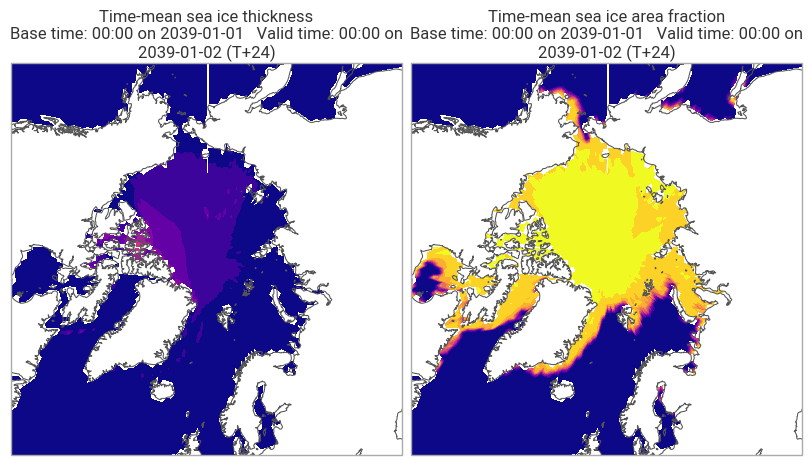

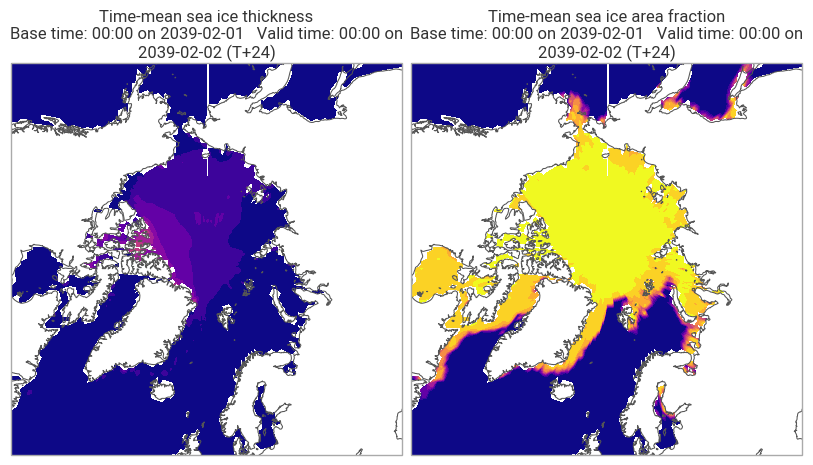

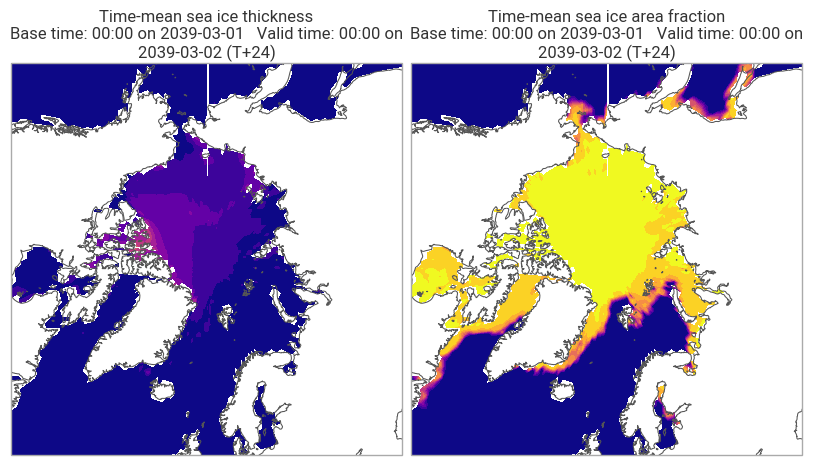

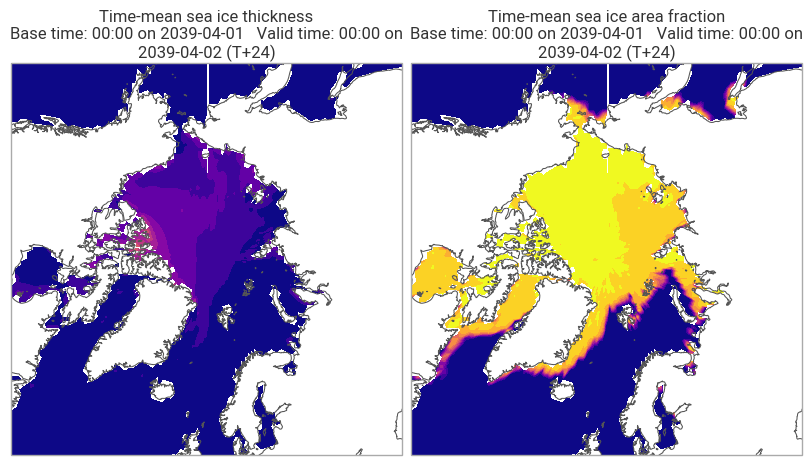

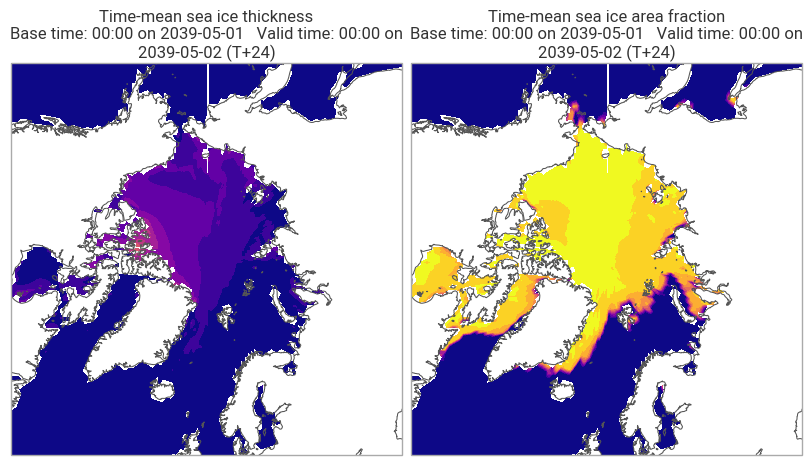

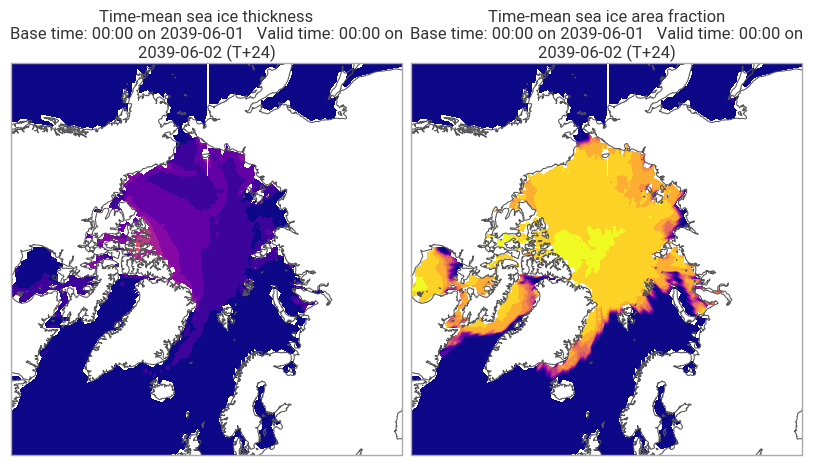

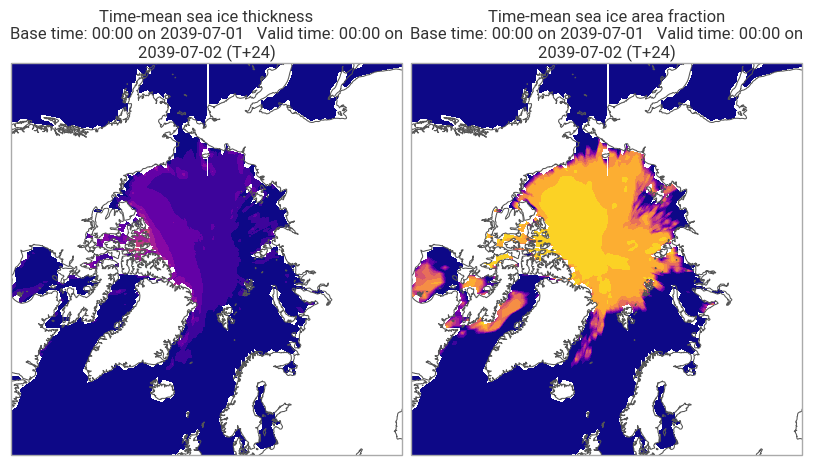

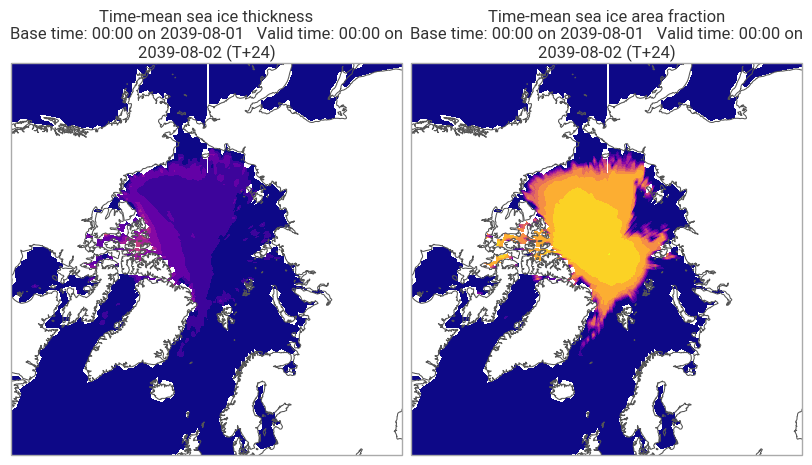

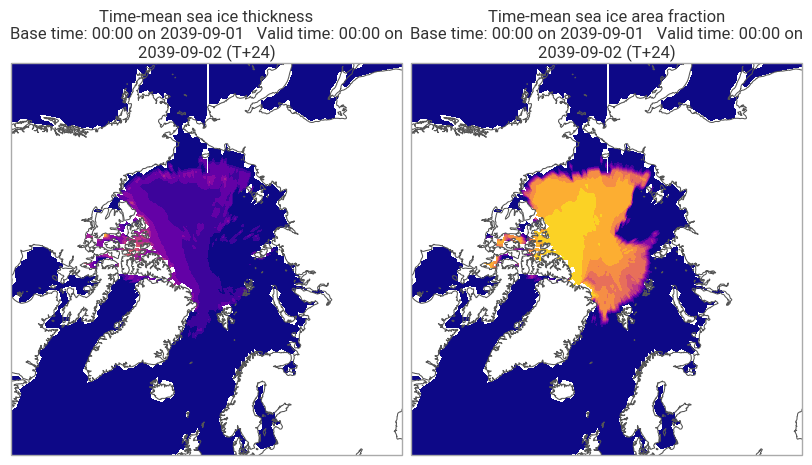

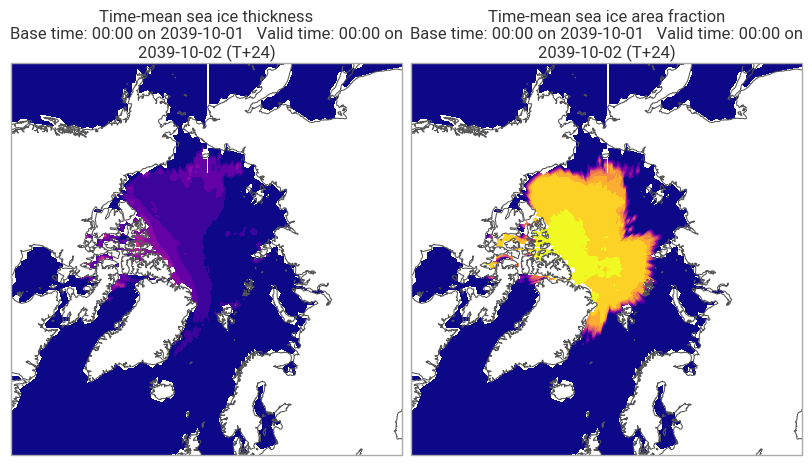

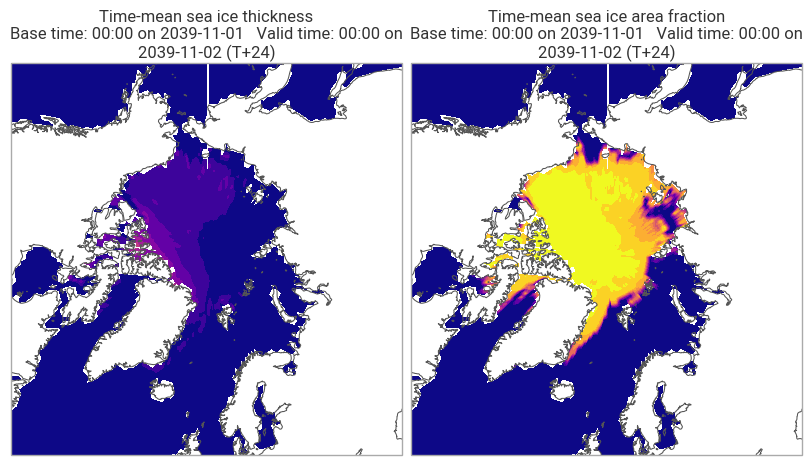

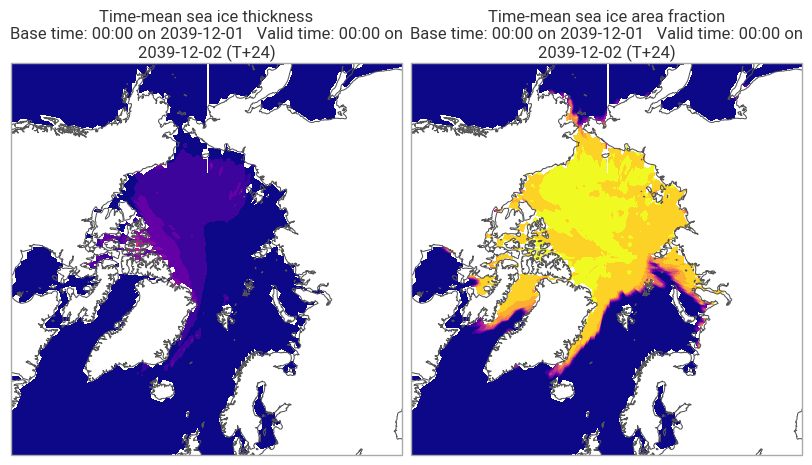

In [6]:
import earthkit.data

# Base request template
request_template = {
    'activity': 'ScenarioMIP',
    'class': 'd1',
    'dataset': 'climate-dt',
    'experiment': 'SSP3-7.0',
    'expver': '0001',
    'generation': '1',
    'levtype': 'o2d',
    'model': 'IFS-NEMO',
    'param': '263000/263001',
    'realization': '1',
    'resolution': 'high',
    'stream': 'clte',
    'time': '0000',
    'type': 'fc'
}

# List to store all the data objects
data_collection = []

# Loop to generate requests for the first day of every month from 2020 to 2024
for year in range(2039, 2040):
    for month in range(1, 13):
        # Format year and month into YYYYMMDD format
        date_str = f"{year:04d}{month:02d}01"

        # Create a copy of the request template and update the date field
        request = request_template.copy()
        request['date'] = date_str

        # Fetch data for the current request
        print(f"Fetching data for {date_str}...")
        data = earthkit.data.from_source(
            "polytope",
            "destination-earth",
            request,
            address="polytope.lumi.apps.dte.destination-earth.eu",
            stream=False
        )
        figure = earthkit.plots.Figure(columns=2, size=(8, 7.5))

        for i, _ in enumerate(range(len(data.ls()))):
            subplot = figure.add_map(domain="Arctic")
            subplot.contourf(data[i])
          
            subplot.title()
            subplot.coastlines()
            
        figure_filename = f"arctic_plot_{date_str}.png"
        figure.save(figure_filename)          # Add fetched data to the collection
        data_collection.append(data)

        print(f"Data for {date_str} fetched successfully.")

In [12]:
import pandas as pd
time_series = pd.date_range(start="2020-01-15", end="2040-1-15", freq="MS") + pd.DateOffset(days=14)

# Display the time series
print(time_series)

plt.plot(time_series, sithick_collection, label='Mean Ice Thickness', color='blue')

# Add title and labels
plt.title("Mean Ice Thickness (80°N–90°N)", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Ice Thickness (m)", fontsize=12)

# Optional: Add grid and legend
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# Display the plot
plt.tight_layout()
plt.savefig('thickness_series.png')

DatetimeIndex(['2020-02-15', '2020-03-15', '2020-04-15', '2020-05-15',
               '2020-06-15', '2020-07-15', '2020-08-15', '2020-09-15',
               '2020-10-15', '2020-11-15',
               ...
               '2039-04-15', '2039-05-15', '2039-06-15', '2039-07-15',
               '2039-08-15', '2039-09-15', '2039-10-15', '2039-11-15',
               '2039-12-15', '2040-01-15'],
              dtype='datetime64[ns]', length=240, freq=None)


NameError: name 'sithick_collection' is not defined